<a href="https://colab.research.google.com/github/wilsonkatam9/Sentiment-analysis-IMBD/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install datasets scikit-learn matplotlib seaborn wordcloud pandas numpy --quiet


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load IMDb dataset (50,000 movie reviews)
dataset = load_dataset('imdb')

train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

# Map labels: 0 = Negative, 1 = Positive
label_map = {0: 'Negative', 1: 'Positive'}
train_df['sentiment'] = train_df['label'].map(label_map)
test_df['sentiment']  = test_df['label'].map(label_map)

print(f"Training samples: {len(train_df)}")
print(f"Testing  samples: {len(test_df)}")
train_df.head(3)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training samples: 25000
Testing  samples: 25000


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,Negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,Negative
2,If only to avoid making this type of film in t...,0,Negative


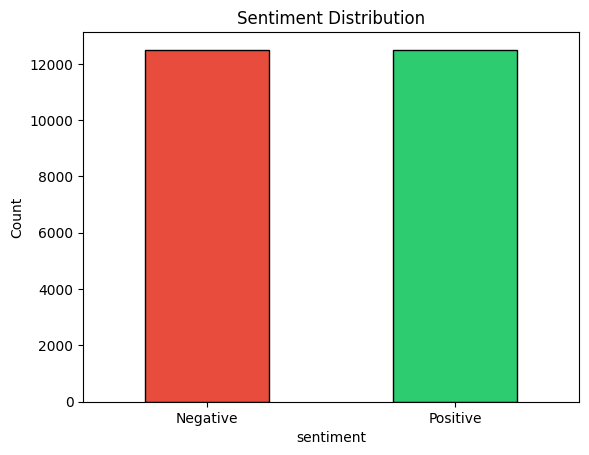

In [5]:
# Check class balance
train_df['sentiment'].value_counts().plot(
    kind='bar', color=['#e74c3c','#2ecc71'],
    title='Sentiment Distribution', edgecolor='black'
)
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

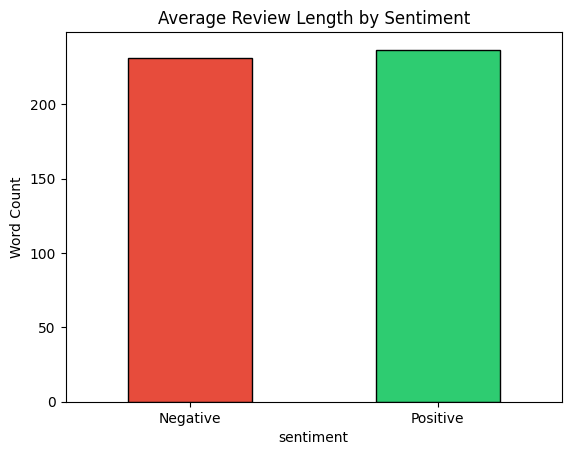

In [6]:
# Review length analysis
train_df['review_length'] = train_df['text'].apply(lambda x: len(x.split()))

train_df.groupby('sentiment')['review_length'].mean().plot(
    kind='bar', color=['#e74c3c','#2ecc71'],
    title='Average Review Length by Sentiment', edgecolor='black'
)
plt.xticks(rotation=0)
plt.ylabel("Word Count")
plt.show()

In [7]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)         # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

print("Text cleaned!")
print(train_df['clean_text'][0][:300])

Text cleaned!
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see th


In [8]:

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words=None,
    min_df=2
)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_test  = test_df['label']

print(" Vectorization done!", X_train.shape)

 Vectorization done! (25000, 20000)


In [9]:
# ---- Logistic Regression ----
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 89.26%


In [10]:
# ----  Naive Bayes ----
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
nb_acc   = accuracy_score(y_test, nb_preds)
print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")

Naive Bayes Accuracy: 86.48%


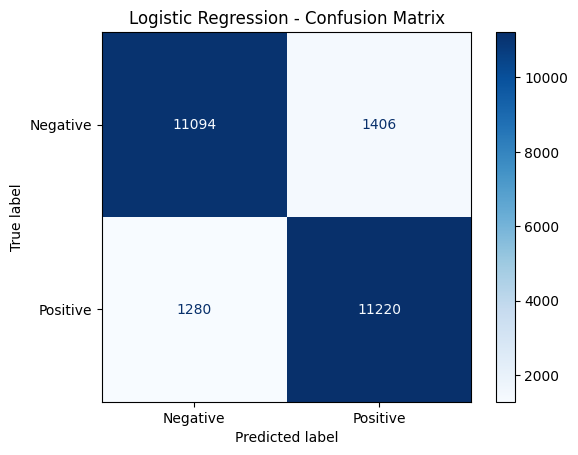

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [11]:
# Confusion Matrix for best model (LR)
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, lr_preds, target_names=['Negative','Positive']))

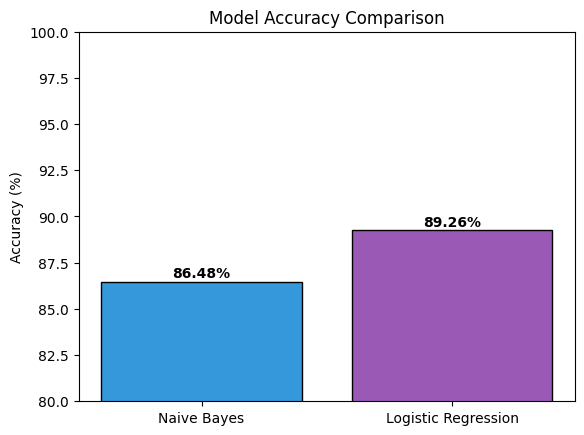

In [12]:
# Model Comparison Bar Chart
models = ['Naive Bayes', 'Logistic Regression']
scores = [nb_acc * 100, lr_acc * 100]

plt.bar(models, scores, color=['#3498db','#9b59b6'], edgecolor='black')
plt.ylim(80, 100)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for i, v in enumerate(scores):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

In [13]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    return "✅ Positive" if prediction == 1 else "❌ Negative"

print(predict_sentiment("This movie was absolutely amazing! I loved every moment."))
print(predict_sentiment("Terrible film. Complete waste of time and money."))
print(predict_sentiment("The plot was okay but the acting was brilliant."))
print(predict_sentiment("This is not at all a good movie"))

✅ Positive
❌ Negative
❌ Negative
❌ Negative


In [14]:
nb_acc = accuracy_score(y_test, nb_preds)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"✅ Naive Bayes Accuracy         : {nb_acc*100:.2f}%")
print(f"✅ Logistic Regression Accuracy : {lr_acc*100:.2f}%")

✅ Naive Bayes Accuracy         : 86.48%
✅ Logistic Regression Accuracy : 89.26%


In [15]:
print("=" * 50)
print("📊 Naive Bayes - Classification Report")
print("=" * 50)
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

print("=" * 50)
print("📊 Logistic Regression - Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

📊 Naive Bayes - Classification Report
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.87     12500
    Positive       0.87      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000

📊 Logistic Regression - Classification Report
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



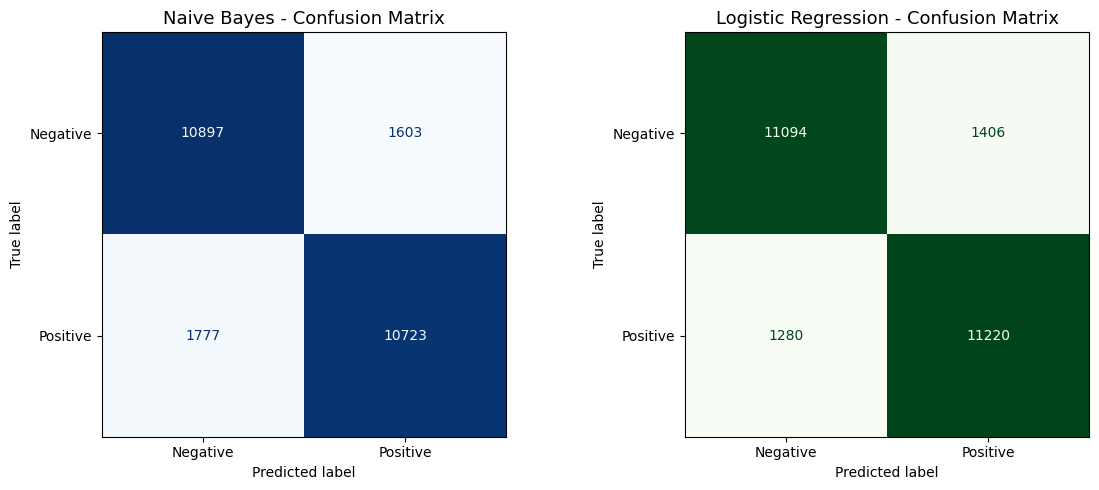

 Confusion Matrix saved!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes
cm_nb = confusion_matrix(y_test, nb_preds)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Negative', 'Positive'])
disp_nb.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Bayes - Confusion Matrix', fontsize=13)

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Negative', 'Positive'])
disp_lr.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Logistic Regression - Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion Matrix saved!")

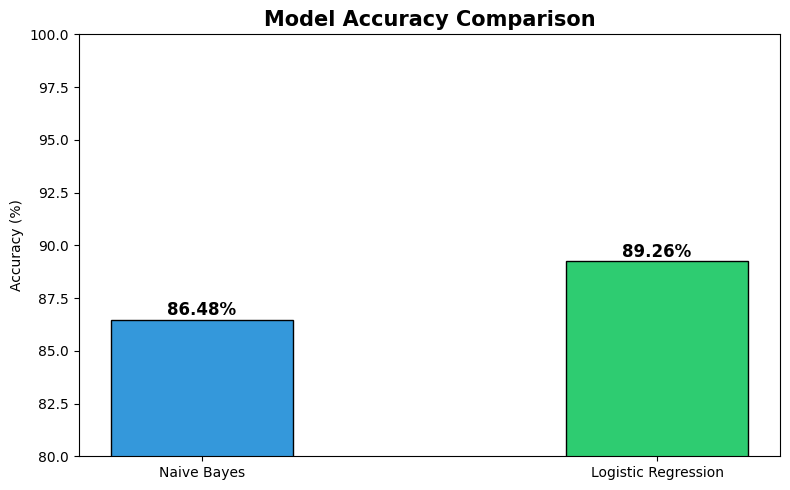

 Model Comparison Chart saved!


In [19]:
models = ['Naive Bayes', 'Logistic Regression']
scores = [nb_acc * 100, lr_acc * 100]
colors = ['#3498db', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=colors, edgecolor='black', width=0.4)
plt.ylim(80, 100)
plt.title("Model Accuracy Comparison", fontsize=15, fontweight='bold')
plt.ylabel("Accuracy (%)")

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f"{score:.2f}%",
             ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Model Comparison Chart saved!")

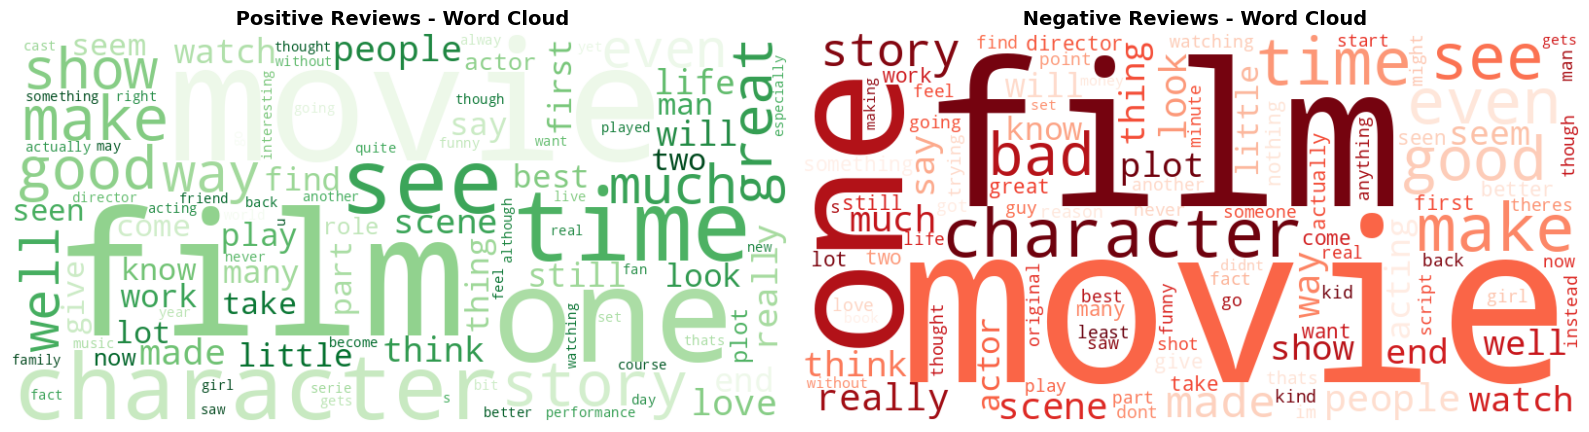

 Word Clouds saved!


In [21]:
from wordcloud import WordCloud

positive_text = ' '.join(train_df[train_df['label'] == 1]['clean_text'])
negative_text = ' '.join(train_df[train_df['label'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive Word Cloud
wc_pos = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap='Greens',
                   max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title(' Positive Reviews - Word Cloud', fontsize=14, fontweight='bold')

# Negative Word Cloud
wc_neg = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap='Reds',
                   max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title(' Negative Reviews - Word Cloud', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Word Clouds saved!")

In [22]:
print(" Testing Custom Reviews")
print("-" * 40)

test_reviews = [
    "This movie was absolutely amazing! I loved every moment.",
    "Terrible film. Complete waste of time and money.",
    "Not a good movie",
    "The acting was brilliant but the story was boring.",
    "One of the best films I have ever watched!",
    "I would never recommend this to anyone."
]

for review in test_reviews:
    result = predict_sentiment(review)
    print(f"{result} → {review}")

 Testing Custom Reviews
----------------------------------------
✅ Positive → This movie was absolutely amazing! I loved every moment.
❌ Negative → Terrible film. Complete waste of time and money.
❌ Negative → Not a good movie
❌ Negative → The acting was brilliant but the story was boring.
✅ Positive → One of the best films I have ever watched!
✅ Positive → I would never recommend this to anyone.
